In [5]:
!pip install numdifftools

  Using cached numdifftools-0.9.42-py3-none-any.whl.metadata (10 kB)
Using cached numdifftools-0.9.42-py3-none-any.whl (94 kB)


In [ ]:
import numpy as np
from scipy.optimize import minimize
import numdifftools as nd
import matplotlib.pyplot as plt

In [9]:
def sigmoid(t, tau, s):
    """Standard logistic sigmoid function."""
    return 1.0 / (1.0 + np.exp(-s * (t - tau)))

# Testing gradient for d_lambda / d_tau_j

In [10]:

def compute_gated_rate(t, lambdas, taus, s):
    """
    Computes lambda(t) using the uniform gating architecture.
    Every state j uses the window: A_j(t) = sigma_j(t) * (1 - sigma_{j+1}(t))
    """
    K = len(taus)

    # Pad taus with virtual boundaries to make all states uniform gates
    # tau_0 = -infinity (so sigma_0(t) = 1)
    # tau_{K+1} = +infinity (so sigma_{K+1}(t) = 0)
    padded_taus = np.concatenate([[-np.inf], taus, [np.inf]])

    # Compute sigmoids for all boundaries j = 0 to K+1
    # For boundaries at infinity, set values explicitly to avoid overflow warnings
    sigmas = []
    for j, tau in enumerate(padded_taus):
        if tau == -np.inf:
            sigmas.append(1.0)
        elif tau == np.inf:
            sigmas.append(0.0)
        else:
            sigmas.append(sigmoid(t, tau, s[j-1])) # s is 0-indexed for j=1..K
    sigmas = np.array(sigmas)

    # Compute activations A_j(t) for j = 0 to K
    # A_j(t) = sigma_j(t) * (1 - sigma_{j+1}(t))
    A = sigmas[:-1] * (1.0 - sigmas[1:])

    # Total instantaneous rate is the dot product of state rates and activations
    lambda_t = np.dot(lambdas, A)
    return lambda_t

def analytical_dlambda_dtau(t, lambdas, taus, s, target_j):
    """
    Analytical formula for d_lambda(t) / d_tau_j:
    s_j * sigma_j * (1 - sigma_j) * [ lambda_{j-1} * sigma_{j-1} - lambda_j * (1 - sigma_{j+1}) ]
    Note: target_j is 1-indexed to match the mathematical notation (j = 1, ..., K)
    """
    # Align 1-indexed target_j to 0-indexed arrays
    j_idx = target_j - 1

    padded_taus = np.concatenate([[-np.inf], taus, [np.inf]])

    # Get the required adjacent sigmoids
    # sigma_{j-1}
    if padded_taus[target_j - 1] == -np.inf:
        sigma_prev = 1.0
    else:
        sigma_prev = sigmoid(t, padded_taus[target_j - 1], s[target_j - 2])

    # sigma_j
    sigma_curr = sigmoid(t, padded_taus[target_j], s[j_idx])

    # sigma_{j+1}
    if padded_taus[target_j + 1] == np.inf:
        sigma_next = 0.0
    else:
        sigma_next = sigmoid(t, padded_taus[target_j + 1], s[target_j])

    # Extracted state values matching the boundary j
    lambda_prev = lambdas[target_j - 1]
    lambda_curr = lambdas[target_j]

    # Evaluate the derived equation
    s_j = s[j_idx]
    scaling_term = s_j * sigma_curr * (1.0 - sigma_curr)
    tension_term = (lambda_prev * sigma_prev) - (lambda_curr * (1.0 - sigma_next))

    return scaling_term * tension_term

# ==========================================
# VERIFICATION EXECUTION
# ==========================================
# Define an arbitrary test environment (K = 2 changepoints -> 3 states)
test_taus = np.array([25.0, 65.0])       # Physical changepoint marks
test_lambdas = np.array([2.5, 12.0, 4.0]) # Baseline emissions per state
test_s = np.array([1.2, 0.8])            # Steepness parameters for the transitions

# Pick a test time point near the first changepoint to get a non-zero gradient
test_t = 26.0
target_changepoint = 1  # We want to check d_lambda / d_tau_1

# 1. Compute Analytical Derivative
deriv_analytical = analytical_dlambda_dtau(
    test_t, test_lambdas, test_taus, test_s, target_j=target_changepoint
)

# 2. Compute Numerical Derivative via Central Finite Differences
epsilon = 1e-6

# Perturb tau_1 up
taus_plus = test_taus.copy()
taus_plus[target_changepoint - 1] += epsilon
lambda_plus = compute_gated_rate(test_t, test_lambdas, taus_plus, test_s)

# Perturb tau_1 down
taus_minus = test_taus.copy()
taus_minus[target_changepoint - 1] -= epsilon
lambda_minus = compute_gated_rate(test_t, test_lambdas, taus_minus, test_s)

# Slope calculation
deriv_numerical = (lambda_plus - lambda_minus) / (2.0 * epsilon)

# 3. Assess Relative Error
abs_error = np.abs(deriv_analytical - deriv_numerical)
rel_error = abs_error / (max(np.abs(deriv_analytical), np.abs(deriv_numerical)) + 1e-15)

print("--- GRADIENT CHECK RESULTS ---")
print(f"Time Step (t):          {test_t}")
print(f"Target Changepoint (j): {target_changepoint}")
print(f"Analytical Derivative:  {deriv_analytical:.10f}")
print(f"Numerical Derivative:   {deriv_numerical:.10f}")
print(f"Absolute Error:         {abs_error:.1e}")
print(f"Relative Error:         {rel_error:.1e}")

if rel_error < 1e-7:
    print("\n✅ SUCCESS: Analytical gradient matches numerical approximation perfectly!")
else:
    print("\n❌ ERROR: Discrepancy detected. Double-check script indices or signs.")

--- GRADIENT CHECK RESULTS ---
Time Step (t):          26.0
Target Changepoint (j): 1
Analytical Derivative:  -2.0279966234
Numerical Derivative:   -2.0279966257
Absolute Error:         2.4e-09
Relative Error:         1.2e-09

✅ SUCCESS: Analytical gradient matches numerical approximation perfectly!


# MLE on dummy data

<>:163: SyntaxWarning: invalid escape sequence '\l'
<>:164: SyntaxWarning: invalid escape sequence '\l'
<>:163: SyntaxWarning: invalid escape sequence '\l'
<>:164: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_6866/3411818889.py:163: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(np.arange(1, T + 1), true_lambda_trajectory, 'g-', lw=2.5, label='Ground Truth $\lambda(t)$')
/tmp/ipykernel_6866/3411818889.py:164: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(np.arange(1, T + 1), fit_trajectory, 'r--', lw=2.5, label='MLE Inferred Fit $\lambda(t)$')
/tmp/ipykernel_6866/3411818889.py:138: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Fitting model via MLE...

--- PARAMETER ESTIMATION SUMMARY ---
True Regimes (Lambdas): [ 3. 15.  5. 10. 15.]   | Estimated: [ 2.5  14.91  5.24  9.61 14.11]
True Changepoints (Taus): [ 30  45  70 120] | Estimated: [ 30.51  44.84  70.25 120.93]


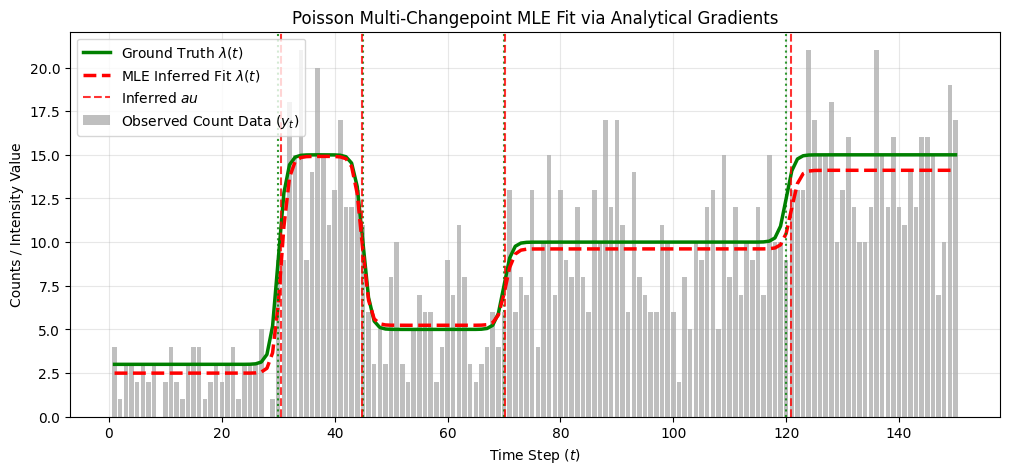

In [7]:
# =====================================================================
# 1. FORWARD MODEL & TRAJECTORY GENERATION
# =====================================================================

def generate_trajectory(T, lambdas, taus, s_vectors):
    """
    Constructs the instantaneous lambda(t) across all t = 1...T.
    Returns lambda_t and the activation matrix A (shape: T x K+1).
    """
    t_arr = np.arange(1, T + 1)
    K = len(taus)

    # Pad changepoints with virtual boundaries
    padded_taus = np.concatenate([[-np.inf], taus, [np.inf]])

    # Pre-calculate sigmoids for all boundaries
    sigmas = np.zeros((T, K + 2))
    sigmas[:, 0] = 1.0  # tau_0 = -inf
    sigmas[:, -1] = 0.0 # tau_{K+1} = +inf
    for j in range(1, K + 1):
        sigmas[:, j] = sigmoid(t_arr, padded_taus[j], s_vectors[j - 1])

    # Calculate uniform gating activations A_j(t) = sigma_j * (1 - sigma_{j+1})
    A = sigmas[:, :-1] * (1.0 - sigmas[:, 1:])

    # Inner dot product sets instantaneous trajectory
    lambda_t = np.dot(A, lambdas)
    return lambda_t, A, sigmas

# =====================================================================
# 2. OBJECTIVE FUNCTION AND ANALYTICAL GRADIENTS
# =====================================================================

def loss_function(params, y, T, K, fixed_s):
    """
    Returns the negative Log-Likelihood and its joint analytical gradients.
    """
    # Unpack unconstrained optimization variables
    log_lambdas = params[:K + 1]
    log_deltas = params[K + 1:]

    # Map back to physical parameters
    lambdas = np.exp(log_lambdas)
    deltas = np.exp(log_deltas)
    taus = np.cumsum(deltas)

    # Compute forward pass trajectories
    lambda_t, A, sigmas = generate_trajectory(T, lambdas, taus, fixed_s)

    # Avoid log(0) issues if optimization steps too far
    lambda_t = np.clip(lambda_t, 1e-10, None)

    # Compute Negative Log-Likelihood (dropping log(y_t!) constant)
    nll = -np.sum(y * np.log(lambda_t) - lambda_t)

    # -----------------------------------------------------------------
    # GRADIENT CALCULATION
    # -----------------------------------------------------------------
    # Base Error Signal (Residual)
    error_signal = (y / lambda_t) - 1.0  # Shape: (T,)

    # 1. Gradient w.r.t. State Regimes (lambdas)
    # d_ell / d_lambda_j = sum_t (error_signal * A_j(t))
    grad_lambdas = np.zeros(K + 1)
    for j in range(K + 1):
        grad_lambdas[j] = np.sum(error_signal * A[:, j])

    # 2. Gradient w.r.t. Physical Changepoints (taus) via Derived Gating Form
    grad_taus = np.zeros(K)
    padded_taus = np.concatenate([[-np.inf], taus, [np.inf]])

    for j in range(1, K + 1):
        sigma_prev = sigmas[:, j - 1]
        sigma_curr = sigmas[:, j]
        sigma_next = sigmas[:, j + 1]

        scaling_term = fixed_s[j - 1] * sigma_curr * (1.0 - sigma_curr)
        tension_term = (lambdas[j - 1] * sigma_prev) - (lambdas[j] * (1.0 - sigma_next))

        dlambda_dtau_j = scaling_term * tension_term
        grad_taus[j - 1] = np.sum(error_signal * dlambda_dtau_j)

    # 3. Chain Rule: Back to Unconstrained Space via Log-Deltas
    grad_log_deltas = np.zeros(K)
    for m in range(K):
        # Accumulate downstream changepoints: delta_m * sum_{j=m}^K (d_ell / d_tau_j)
        grad_log_deltas[m] = deltas[m] * np.sum(grad_taus[m:])

    # Chain Rule: Back to Unconstrained Space via Log-Lambdas
    grad_log_lambdas = grad_lambdas * lambdas

    # Assemble Joint Gradient Vector (Invert signs for *Negative* Log-Likelihood)
    joint_grad = -np.concatenate([grad_log_lambdas, grad_log_deltas])

    return nll, joint_grad

# =====================================================================
# 3. EXECUTION BLOCK
# =====================================================================
if __name__ == "__main__":
    np.random.seed(42)
    T = 150
    K = 4  # 4 Changepoints -> 5 states

    # Ground Truth Physical Parameters
    true_lambdas = np.array([3.0, 15.0, 5.0, 10, 15])
    true_taus = np.array([30, 45, 70, 120])
    fixed_s = np.array([1.5, 1.5, 1.5, 1.5]) # Fix transition sharpness

    # Generate Synthetic Dataset
    true_lambda_trajectory, _, _ = generate_trajectory(T, true_lambdas, true_taus, fixed_s)
    y_data = np.random.poisson(true_lambda_trajectory)

    # Initial Parameter Guesses (Deliberately off-center)
    init_lambdas = np.array([5.0, 5.0, 5.0, 5, 5])
    init_taus = np.linspace(0, T, K+2)[1:-1] # Evenly distributed guesses

    # Convert initial guesses into unconstrained parameter space
    init_log_lambdas = np.log(init_lambdas)
    init_deltas = np.zeros(K)
    init_deltas[0] = init_taus[0]
    for i in range(1, K):
        init_deltas[i] = init_taus[i] - init_taus[i-1]
    init_log_deltas = np.log(init_deltas)

    init_params = np.concatenate([init_log_lambdas, init_log_deltas])

    # Run the bounded/gradient-driven L-BFGS-B Optimizer
    print("Fitting model via MLE...")
    res = minimize(
        fun=loss_function,
        x0=init_params,
        args=(y_data, T, K, fixed_s),
        jac=True, # Inform scipy we are providing the analytical gradients
        method='L-BFGS-B',
        options={'disp': True, 'maxiter': 200}
    )

    # Extract Optimized Parameters
    fit_log_lambdas = res.x[:K + 1]
    fit_log_deltas = res.x[K + 1:]

    fit_lambdas = np.exp(fit_log_lambdas)
    fit_taus = np.cumsum(np.exp(fit_log_deltas))
    fit_trajectory, _, _ = generate_trajectory(T, fit_lambdas, fit_taus, fixed_s)

    # Print Comparison Table
    print("\n--- PARAMETER ESTIMATION SUMMARY ---")
    print(f"True Regimes (Lambdas): {true_lambdas}   | Estimated: {np.round(fit_lambdas, 2)}")
    print(f"True Changepoints (Taus): {true_taus} | Estimated: {np.round(fit_taus, 2)}")

    # Plot the results
    plt.figure(figsize=(12, 5))
    plt.bar(np.arange(1, T + 1), y_data, color='gray', alpha=0.5, label='Observed Count Data ($y_t$)')
    plt.plot(np.arange(1, T + 1), true_lambda_trajectory, 'g-', lw=2.5, label='Ground Truth $\lambda(t)$')
    plt.plot(np.arange(1, T + 1), fit_trajectory, 'r--', lw=2.5, label='MLE Inferred Fit $\lambda(t)$')

    for tc in true_taus:
        plt.axvline(tc, color='green', linestyle=':', alpha=0.8)
    for fc in fit_taus:
        plt.axvline(fc, color='red', linestyle='--', alpha=0.8, label='Inferred $\tau$' if fc == fit_taus[0] else "")

    plt.title("Poisson Multi-Changepoint MLE Fit via Analytical Gradients")
    plt.xlabel("Time Step ($t$)")
    plt.ylabel("Counts / Intensity Value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Laplace Approximation using derived gradients

<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:60: SyntaxWarning: invalid escape sequence '\l'
<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:60: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_6866/1912308545.py:59: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(np.arange(1, T + 1), true_lambda_trajectory, 'g-', lw=2, label='Ground Truth $\lambda(t)$')
/tmp/ipykernel_6866/1912308545.py:60: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(np.arange(1, T + 1), fit_trajectory, 'r--', lw=2.5, label='MLE Fit $\lambda(t)$')
/tmp/ipykernel_6866/3411818889.py:11: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-s * (t - tau)))



Computing robust numerical Hessian via numdifftools...


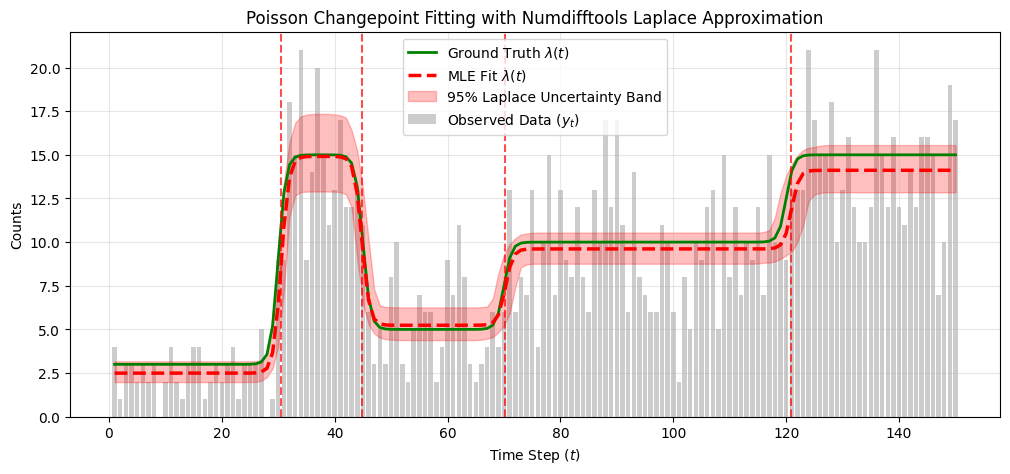

In [8]:

mle_mode = res.x

# -----------------------------------------------------------------
# INTEGRATING NUMDIFFTOOLS FOR AUTOMATED STEP-SIZE HESSIAN
# -----------------------------------------------------------------
# We wrap our loss function to return ONLY the gradient vector
# because differentiating the gradient yields the Hessian matrix directly.
def grad_objective_wrapper(params):
    _, joint_grad = loss_function(params, y_data, T, K, fixed_s)
    return joint_grad

print("\nComputing robust numerical Hessian via numdifftools...")
# nd.Jacobian of the gradient yields the Hessian matrix of the scalar loss
n_params = len(mle_mode)
hessian_computer = nd.Jacobian(grad_objective_wrapper)
H_negative = hessian_computer(mle_mode)

# Symmetrize and add a tiny ridge stabilizer to guarantee invertibility
H_negative = 0.5 * (H_negative + H_negative.T)
H_stabilized = H_negative + 1e-5 * np.eye(n_params)

# Extract Covariance Matrix via inversion
Sigma = np.linalg.inv(H_stabilized)

# -----------------------------------------------------------------
# DRAW LAPLACE POSTERIOR SAMPLES
# -----------------------------------------------------------------
n_samples = 1000
sampled_parameters = np.random.multivariate_normal(mle_mode, Sigma, size=n_samples)
sampled_trajectories = np.zeros((n_samples, T))

for s_idx in range(n_samples):
    s_lambdas = np.exp(sampled_parameters[s_idx, :K + 1])
    s_taus = np.cumsum(np.exp(sampled_parameters[s_idx, K + 1:]))
    traj, _, _ = generate_trajectory(T, s_lambdas, s_taus, fixed_s)
    sampled_trajectories[s_idx, :] = traj

lower_bound = np.percentile(sampled_trajectories, 2.5, axis=0)
upper_bound = np.percentile(sampled_trajectories, 97.5, axis=0)

# Reconstruct final MLE path for visualization
fit_lambdas = np.exp(mle_mode[:K + 1])
fit_taus = np.cumsum(np.exp(mle_mode[K + 1:]))
fit_trajectory, _, _ = generate_trajectory(T, fit_lambdas, fit_taus, fixed_s)

# -----------------------------------------------------------------
# VISUALIZE PROBABILISTIC INFERENCE BANDS
# -----------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.bar(np.arange(1, T + 1), y_data, color='gray', alpha=0.4, label='Observed Data ($y_t$)')
plt.plot(np.arange(1, T + 1), true_lambda_trajectory, 'g-', lw=2, label='Ground Truth $\lambda(t)$')
plt.plot(np.arange(1, T + 1), fit_trajectory, 'r--', lw=2.5, label='MLE Fit $\lambda(t)$')
plt.fill_between(np.arange(1, T + 1), lower_bound, upper_bound, color='red', alpha=0.25, label='95% Laplace Uncertainty Band')

for fc in fit_taus:
    plt.axvline(fc, color='red', linestyle='--', alpha=0.7)

plt.title("Poisson Changepoint Fitting with Numdifftools Laplace Approximation")
plt.xlabel("Time Step ($t$)")
plt.ylabel("Counts")
plt.legend()
plt.grid(alpha=0.3)
plt.show()